### Simulate some data

In [5]:
import sys
sys.path.append("..")

from nodegamlss.model import NodeGAMLSS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Generate dataset
N = 5000
x1 = np.random.uniform(-5, 5, size=N)
x2 = np.random.uniform(-5, 5, size=N)
x3 = np.random.uniform(-5, 5, size=N)

f1 = lambda x: (x) ** 2 - 8
f2 = lambda x: x * 2
f3 = lambda x: np.sin(x)

y = f1(x1) + f2(x2) + f3(x3) + np.random.normal(0,0.5, N)
y = (y - np.mean(y)) / np.std(y)
X = pd.DataFrame(np.vstack([x1, x2, x3]).T)



#### Visualize simulated data

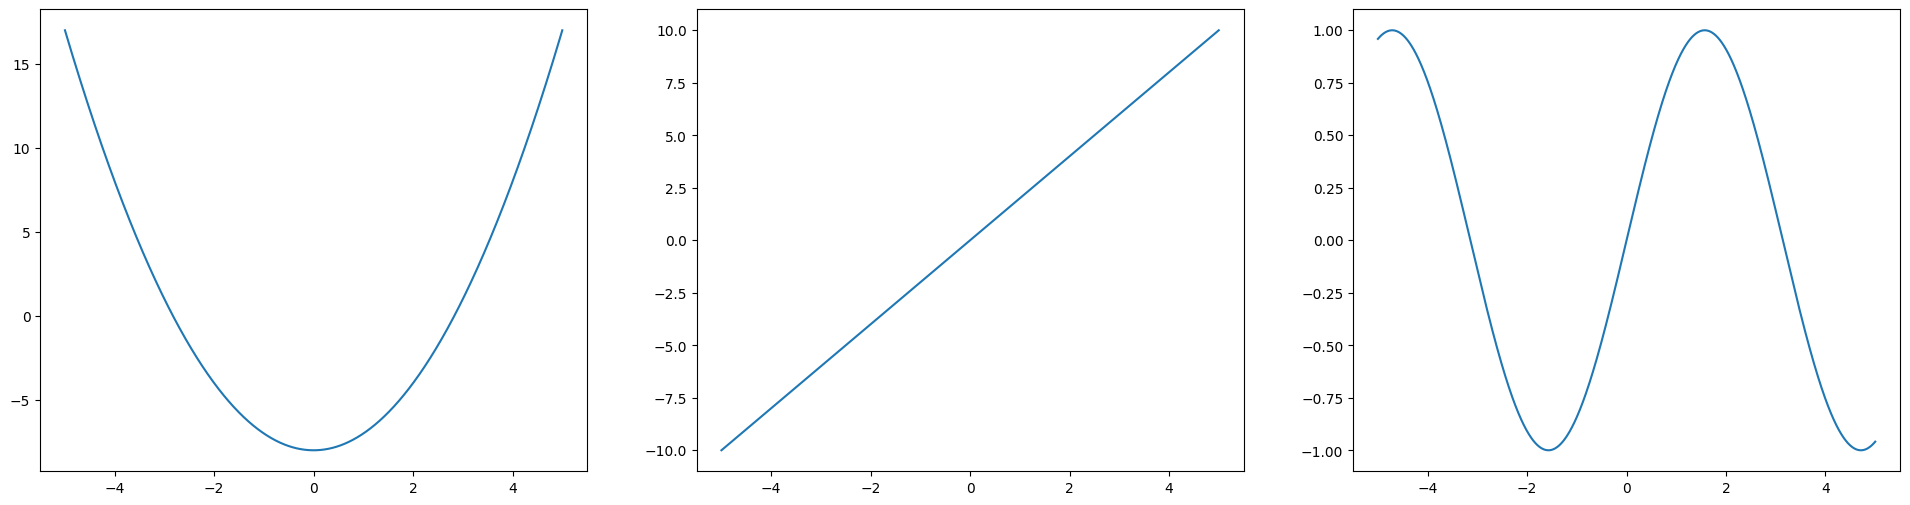

In [6]:
x = np.linspace(-5, 5, 1000)
fig, ax = plt.subplots(1, 3, figsize=(24, 6))
ax[0].plot(x, f1(x))
ax[1].plot(x, f2(x))
ax[2].plot(x, f3(x))

## Fit NodeGAMLSS
Use Normal distribution, minimize neg-log-lik

In [8]:
model = NodeGAMLSS(
    in_features=X.shape[1],
    family="normal",
    device="cpu",
    verbose=False,
    max_steps=100,
    lr=0.001,
    report_frequency=100,
    num_trees=75
)


record = model.fit(X, y)

/home/ananyapam/miniconda3/envs/nodegamlss/lib/python3.9/site-packages/qhoptim/pyt/qhadam.py:133: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha) (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:1578.)
  exp_avg.mul_(beta1_adj).add_(1.0 - beta1_adj, d_p)


Step      	NLL            	mse            	mae            	rmse           
100       	1.4866         	0.9537         	0.7534         	0.9766         
End. It reaches the maximum steps 100
Total training time: 21.3 seconds
Best step:  100
Best Val Metric:  1.4866191
Load the best checkpoint.


# Visualize
 plots are shown in order of distributional parameters as defined by the distribution in torch.distributions. 
 First row thus shows mean, second shows variance (before softplus transformation)

bin features 0 with uniq val 4998 to only 256
bin features 1 with uniq val 5000 to only 256
bin features 2 with uniq val 5000 to only 256
Finish "Run values through model" in 157ms


100%|██████████| 6/6 [00:00<00:00, 140.53it/s]


Finish "Extract values" in 48ms
Finish "Purify interactions to main effects" in 48ms
Finish "Center main effects" in 1ms


100%|██████████| 7/7 [00:00<00:00, 34.14it/s]


Finish "Construct table" in 211ms
Finish "Run values through model" in 128ms


100%|██████████| 6/6 [00:00<00:00, 164.57it/s]


Finish "Extract values" in 41ms
Finish "Purify interactions to main effects" in 44ms
Finish "Center main effects" in 1ms


100%|██████████| 7/7 [00:00<00:00, 16.37it/s]


Finish "Construct table" in 434ms


([<Figure size 2200x800 with 11 Axes>, <Figure size 2200x800 with 11 Axes>],
 [array([[<Axes: title={'center': '0 (Imp=0.103)'}>,
          <Axes: title={'center': '1 (Imp=0.204)'}>,
          <Axes: title={'center': '2 (Imp=0.047)'}>,
          <Axes: title={'center': '0_1 (Imp=0.026)'}, xlabel='0', ylabel='1'>],
         [<Axes: title={'center': '0_2 (Imp=0.014)'}, xlabel='0', ylabel='2'>,
          <Axes: title={'center': '1_2 (Imp=0.0)'}, xlabel='1', ylabel='2'>,
          <Axes: >, <Axes: >]], dtype=object),
  array([[<Axes: title={'center': '0 (Imp=0.225)'}>,
          <Axes: title={'center': '1 (Imp=0.079)'}>,
          <Axes: title={'center': '2 (Imp=0.036)'}>,
          <Axes: title={'center': '0_1 (Imp=0.013)'}, xlabel='0', ylabel='1'>],
         [<Axes: title={'center': '0_2 (Imp=0.01)'}, xlabel='0', ylabel='2'>,
          <Axes: title={'center': '1_2 (Imp=0.0)'}, xlabel='1', ylabel='2'>,
          <Axes: >, <Axes: >]], dtype=object)],
 [  feat_name feat_idx                 

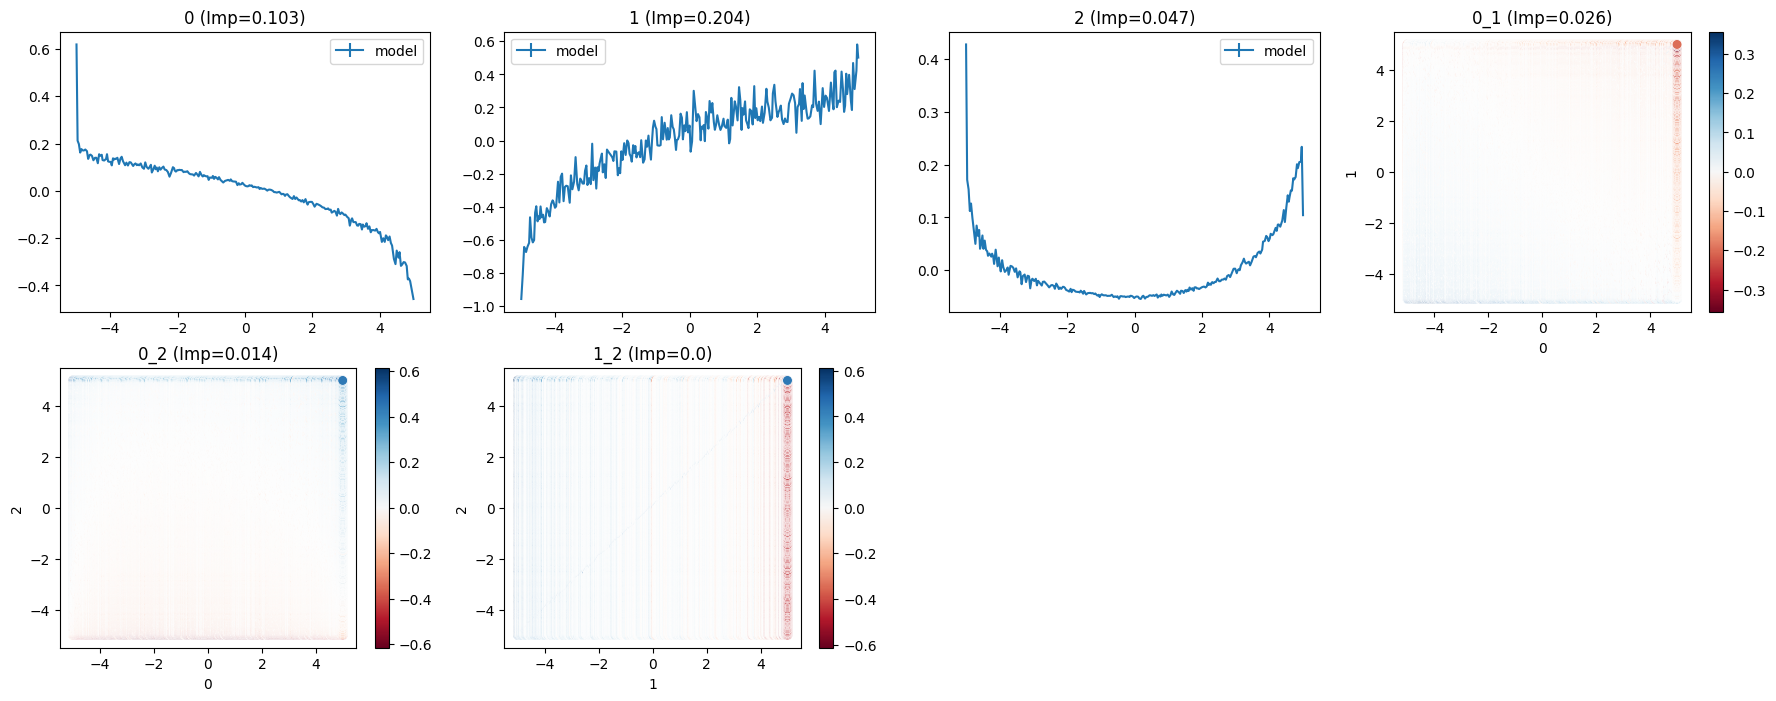

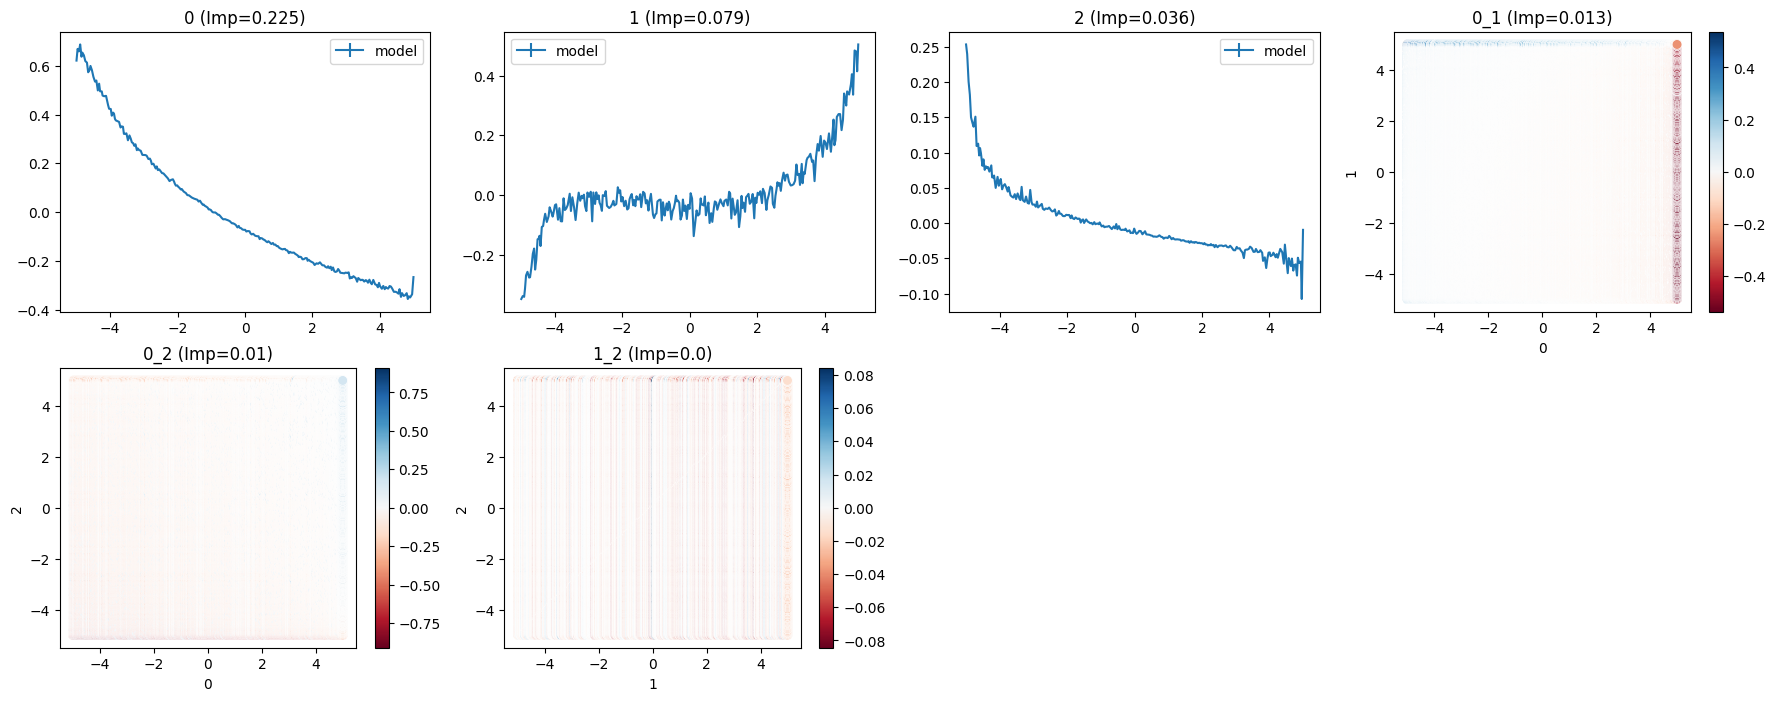

In [9]:
model.visualize_nodegam(X)

In [12]:
model.plot_single_feature_effects(X, parameter="mean")

bin features 0 with uniq val 4998 to only 256
bin features 1 with uniq val 5000 to only 256
bin features 2 with uniq val 5000 to only 256
Finish "Run values through model" in 138ms


100%|██████████| 6/6 [00:00<00:00, 181.99it/s]

Finish "Extract values" in 38ms


Finish "Purify interactions to main effects" in 66ms
Finish "Center main effects" in 1ms


100%|██████████| 7/7 [00:00<00:00, 26.42it/s]


Finish "Construct table" in 270ms
Finish "Run values through model" in 132ms


100%|██████████| 6/6 [00:00<00:00, 180.59it/s]


Finish "Extract values" in 39ms
Finish "Purify interactions to main effects" in 60ms
Finish "Center main effects" in 1ms


100%|██████████| 7/7 [00:00<00:00, 14.80it/s]

Finish "Construct table" in 478ms


In [13]:
model.plot_single_feature_effects(X, parameter="variance")

bin features 0 with uniq val 4998 to only 256
bin features 1 with uniq val 5000 to only 256
bin features 2 with uniq val 5000 to only 256
Finish "Run values through model" in 191ms


100%|██████████| 6/6 [00:00<00:00, 84.10it/s]


Finish "Extract values" in 78ms
Finish "Purify interactions to main effects" in 67ms
Finish "Center main effects" in 1ms


100%|██████████| 7/7 [00:00<00:00, 27.97it/s]


Finish "Construct table" in 260ms
Finish "Run values through model" in 135ms


100%|██████████| 6/6 [00:00<00:00, 208.15it/s]


Finish "Extract values" in 33ms
Finish "Purify interactions to main effects" in 42ms
Finish "Center main effects" in 1ms


100%|██████████| 7/7 [00:00<00:00, 27.82it/s]


Finish "Construct table" in 257ms


In [14]:
model.plot_interaction_effects(X, port=8051, parameter="mean")

bin features 0 with uniq val 4998 to only 256
bin features 1 with uniq val 5000 to only 256
bin features 2 with uniq val 5000 to only 256
Finish "Run values through model" in 160ms


100%|██████████| 6/6 [00:00<00:00, 123.26it/s]


Finish "Extract values" in 57ms
Finish "Purify interactions to main effects" in 86ms
Finish "Center main effects" in 1ms


100%|██████████| 7/7 [00:00<00:00, 14.63it/s]


Finish "Construct table" in 485ms
Finish "Run values through model" in 189ms


100%|██████████| 6/6 [00:00<00:00, 91.67it/s]


Finish "Extract values" in 78ms
Finish "Purify interactions to main effects" in 86ms
Finish "Center main effects" in 1ms


100%|██████████| 7/7 [00:00<00:00, 20.58it/s]

Finish "Construct table" in 348ms


## Visualize training loss

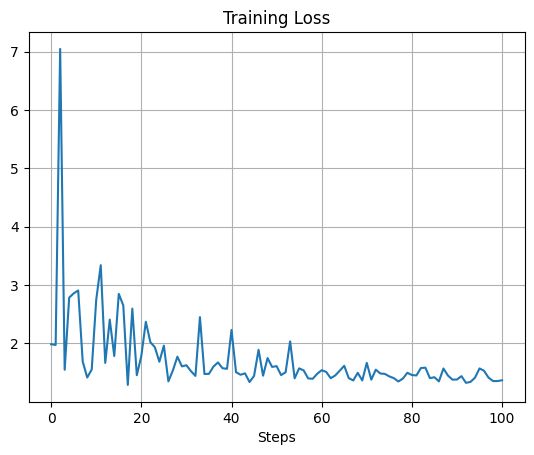

In [18]:
# plt.figure(figsize=[18, 6])
plt.plot(record['train_losses'])
plt.title('Training Loss')
plt.xlabel('Steps')
plt.grid()
plt.show()